# Hands-On GeoAI Tutorial Notebook 1: ML Classification with Vienna Airbnb Data

## Predicting whether a Vienna airbnb listing is highly rated or not

In this notebook, we move from raw geospatial Airbnb data to a fully evaluated classification workflow.

Our story is simple:

- every Airbnb listing is a **point in space**
- every neighborhood is a **polygon**
- machine learning needs **clean numerical representations**
- and a fair model must be tested on data it never saw during training.

To achieve this, we need to:

1. load and understand the data  
2. engineer a few useful features  
3. train **one classifier step by step**  
4. generalize the same logic to **multiple classifiers**  
5. compare them visually  
6. optional: play with a few hyperparameters  

We keep the focus on the supervised-learning ideas from class:

- classification
- train/test split
- preprocessing
- pipelines
- model evaluation


## Notebook setup: install required libraries

If you are running this notebook in **Binder** or another temporary cloud environment, some Python libraries used in this course may not already be available.

Please **uncomment** and run the next code cell **once at the beginning of the notebook**.

Why do we do this?
- Binder sessions are temporary, so package availability can vary.
- Installing the required libraries at the start helps make sure everyone is working in the same software environment.
- This is especially important for geospatial libraries such as **GeoPandas**, which are needed to read and work with spatial data.

How to use it:
1. Run the next code cell.
2. Wait until the installation finishes.
3. If Binder asks you to restart the kernel, do that.
4. Then continue running the notebook from top to bottom.

Required external libraries in this course:
- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn
- geopandas
- pyogrio

In [28]:
## Run this cell once at the start of the notebook when using Binder

#!pip install -q numpy pandas matplotlib seaborn scikit-learn geopandas pyogrio
#print("Setup complete. If you see any import errors later, restart the kernel and run the notebook again from the top.")

In [29]:
# ============================================================
# 0. Imports and notebook settings
# ============================================================
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 120)
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


## Semi-goal 1 — Load the data and make it spatial

A GeoAI notebook should not treat location as just another spreadsheet column.

So we begin by:

- loading the Airbnb listings table
- loading Vienna neighbourhood polygons
- converting listings into points
- spatially joining each point to a neighbourhood polygon

That gives us a geospatially meaningful dataset for later machine learning.

In [30]:
# ============================================================
# 1. Resolve the file paths
# ============================================================
DATA_DIRS = [
    Path("."),
    Path("./data"),
]

def find_file(filename):
    for folder in DATA_DIRS:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in any of: {DATA_DIRS}")

csv_path = find_file("listings_Vienna.csv")
geojson_path = find_file("neighbourhoods.geojson")

print("CSV path:", csv_path)
print("GeoJSON path:", geojson_path)

CSV path: data\listings_Vienna.csv
GeoJSON path: data\neighbourhoods.geojson


In [31]:
# ============================================================
# 2. Load the raw Airbnb table and the neighbourhood polygons
# ============================================================
df = pd.read_csv(csv_path)
neighbourhoods = gpd.read_file(geojson_path)
#neighbourhoods.head()

In [32]:
# Turn the Airbnb table into a GeoDataFrame so that each listing becomes a point.
airbnb_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# Spatial join: assign each point listing to the polygon that contains it.
spatial = gpd.sjoin(
    airbnb_gdf,
    neighbourhoods[["neighbourhood", "geometry"]],
    how="left",
    predicate="within",
)

# The spatial join creates both left and right neighbourhood columns.
spatial = spatial.rename(columns={"neighbourhood_right": "neighbourhood_joined"})

# If a point does not match a polygon, fall back to the original cleaned neighbourhood column.
spatial["neighbourhood_joined"] = spatial["neighbourhood_joined"].fillna(
    spatial["neighbourhood_cleansed"]
)

print("Original table shape:", df.shape)
print("Spatial table shape: ", spatial.shape)
display(spatial[[
    "latitude", "longitude", "neighbourhood_cleansed", "neighbourhood_joined"
]].head())

Original table shape: (14123, 79)
Spatial table shape:  (14123, 82)


,latitude,longitude,neighbourhood_cleansed,neighbourhood_joined
0,48.18434,16.32701,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
1,48.21778,16.37847,Leopoldstadt,Leopoldstadt
2,48.18467,16.32795,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
3,48.18445,16.32722,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
4,48.21543,16.30939,Ottakring,Ottakring


## Quick map check

Before modeling, we should always ask:

> Do the points and polygons look sensible together?

A quick visual inspection often catches problems that would otherwise silently propagate into the model.

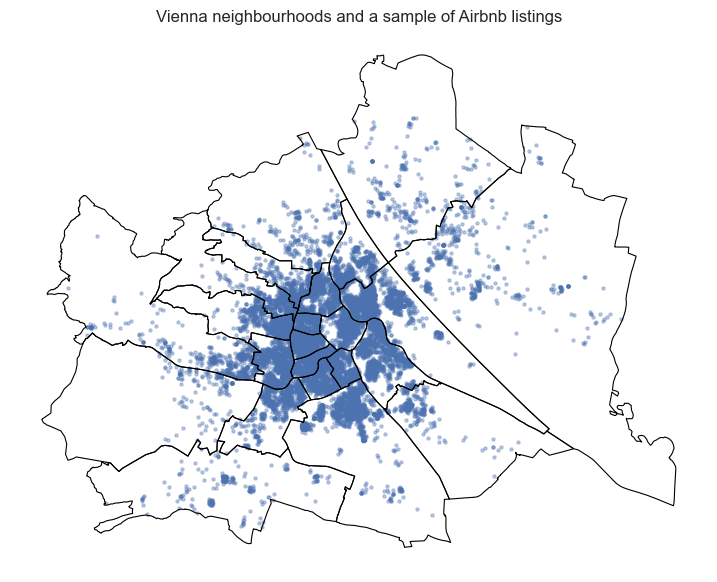

In [33]:
# ============================================================
# 3. Quick map check
# ============================================================
fig, ax = plt.subplots(figsize=(9, 9))
neighbourhoods.boundary.plot(ax=ax, linewidth=0.8, color="black")

# Plot only a sample of points so the map stays readable.
spatial.sample(len(spatial), random_state=RANDOM_STATE).plot(
    ax=ax,
    markersize=5,
    alpha=0.35,
)

ax.set_title("Vienna neighbourhoods and a sample of Airbnb listings")
ax.set_axis_off()
plt.show()

## Semi-goal 2 — Define the classification task

In this part, we prepare the dataset for a **classification problem**.

Our goal is to predict whether an Airbnb listing is **highly rated** or not.

We define the target as:

- `highly_rated = 1` if `review_scores_rating >= 4.8`
- `highly_rated = 0` otherwise

This turns the problem into a **binary classification task**, because there are only two possible classes:
- class 1: highly rated
- class 0: not highly rated

To make this classification problem more meaningful, we only keep listings that have received at least a few reviews.  
This is important because a listing with only one or two reviews may not yet have a stable or trustworthy rating.

---

## Why we need feature engineering

Real datasets are often messy. Important information may not yet be in a form that a machine learning model can use directly.

For example:

- percentages may be stored as text such as `"95%"`
- true/false values may be stored as `"t"` and `"f"`
- bathroom information may be stored as text such as `"1 bath"` or `"Half-bath"`
- amenities may be stored as a text list
- price may be stored as a string such as `"$120.00"`

Machine learning models work best when features are stored as **clean numeric values**.

So in this step, we build a few small helper functions to convert messy columns into useful numeric features.

These helper functions do not train the model.  
They simply **clean, convert, and organize the data** so that the model can later learn from it.

---

## What each helper function does

We use five small helper functions:

1. **`parse_percent()`**  
   Converts percentage text like `"95%"` into a numeric value like `0.95`.

2. **`parse_tf()`**  
   Converts text values such as `"t"` / `"f"` or `"yes"` / `"no"` into `1` and `0`.

3. **`parse_bathrooms()`**  
   Extracts a bathroom count from text such as `"1 bath"` or `"2 baths"`.

4. **`count_amenities()`**  
   Counts how many amenities are listed for a property.

5. **`parse_price()`**  
   Converts a price string such as `"$145.00"` into a numeric value like `145.0`.

---

## Why these functions are useful

These functions help us create features that are:

- easier to understand
- easier to analyze
- ready for machine learning models

For example, a model cannot directly learn well from a string like `"90%"`, but it can learn from a number like `0.90`.

Similarly, a model cannot easily interpret `"t"` and `"f"` as logical categories unless we convert them into numbers such as `1` and `0`.

---

## At this stage, we are not yet "doing machine learning."

We are doing **data preparation** so that later the machine learning model receives input in a clean and consistent format.


In [34]:
# ============================================================
# 3. Feature engineering
# ============================================================
# In this section, we convert messy real-world text columns
# into cleaner numeric variables that are easier for analysis
# and machine learning models to use.


def parse_percent(value):
    """
    Convert a percentage stored as text into a decimal number.

    Examples:
    "95%"  -> 0.95
    "80%"  -> 0.80
    NaN    -> NaN

    Why do we need this?
    Some Airbnb columns such as host response rate are stored
    as strings with a % sign. Machine learning models need
    numeric input, so we convert them into decimal numbers.
    """
    if pd.isna(value):
        return np.nan

    # Convert the value to text, remove spaces, and remove the % sign
    text = str(value).strip().replace("%", "")

    # If the result is empty, treat it as missing
    if text == "":
        return np.nan

    try:
        # Convert to float and divide by 100
        return float(text) / 100.0
    except ValueError:
        # If conversion fails, return missing value
        return np.nan


def parse_tf(value):
    """
    Convert true/false-like text into 1/0.

    Examples:
    "t", "true", "yes", "1" -> 1
    "f", "false", "no", "0" -> 0
    anything else           -> NaN

    Why do we need this?
    Some yes/no columns are stored as text. Models work better
    when these are represented numerically as 1 and 0.
    """
    if pd.isna(value):
        return np.nan

    # Standardize the text by removing spaces and converting to lowercase
    text = str(value).strip().lower()

    if text in {"t", "true", "yes", "1"}:
        return 1

    if text in {"f", "false", "no", "0"}:
        return 0

    # Unknown values are treated as missing
    return np.nan


def parse_bathrooms(text):
    """
    Extract a bathroom count from text.

    Examples:
    "1 bath"       -> 1.0
    "1.5 baths"    -> 1.5
    "Half-bath"    -> 0.5
    missing value  -> NaN

    Why do we need this?
    Bathroom information is often stored as descriptive text,
    but for analysis we want a clean numeric feature.
    """
    if pd.isna(text):
        return np.nan

    # Convert to lowercase text for easier matching
    s = str(text).lower()

    # Special case: half-bath
    if "half-bath" in s:
        return 0.5

    # Use regular expression to find the first number in the text
    match = re.search(r"(\d+(?:\.\d+)?)", s)
    if match:
        return float(match.group(1))

    # If the word "bath" appears but no number is found,
    # assume 1.0 as a fallback
    if "bath" in s:
        return 1.0

    return np.nan


def count_amenities(text):
    """
    Count the number of amenities listed for a property.

    Examples:
    '["Wifi","Kitchen","Heating"]' -> 3
    '[]'                           -> 0
    missing value                  -> NaN

    Why do we need this?
    The original amenities column is stored as text, often in
    a list-like format. A simple summary feature is the total
    number of amenities offered.
    """
    if pd.isna(text):
        return np.nan

    s = str(text).strip()

    # Empty list means zero amenities
    if s in {"", "[]"}:
        return 0

    try:
        # Try to interpret the text as a Python list
        items = ast.literal_eval(s)
        if isinstance(items, (list, tuple, set)):
            return len(items)
    except Exception:
        # If parsing fails, continue to fallback logic
        pass

    # Fallback: manually split the text representation
    s = s.strip("[]")
    if not s:
        return 0

    parts = [part for part in s.split('","') if part.strip()]
    return len(parts)


def parse_price(value):
    """
    Convert a price stored as text into a numeric value.

    Examples:
    "$120.00" -> 120.0
    "1,250"   -> 1250.0
    NaN       -> NaN

    Why do we need this?
    Prices are often stored with currency symbols and commas.
    For analysis and regression, we need them as numeric values.
    """
    if pd.isna(value):
        return np.nan

    # Remove currency symbol and commas, then trim spaces
    text = str(value).replace("$", "").replace(",", "").strip()

    if text == "":
        return np.nan

    try:
        return float(text)
    except ValueError:
        return np.nan


# Make a working copy of the spatially joined data
# so we do not accidentally modify the earlier dataframe
prep_df = spatial.copy()


# ------------------------------------------------------------
# Apply helper functions to create new engineered features
# ------------------------------------------------------------
# Here we convert messy raw columns into cleaner numeric columns.

prep_df["host_response_rate_num"] = prep_df["host_response_rate"].map(parse_percent)
prep_df["host_acceptance_rate_num"] = prep_df["host_acceptance_rate"].map(parse_percent)

prep_df["host_is_superhost_num"] = prep_df["host_is_superhost"].map(parse_tf)
prep_df["host_identity_verified_num"] = prep_df["host_identity_verified"].map(parse_tf)
prep_df["instant_bookable_num"] = prep_df["instant_bookable"].map(parse_tf)

prep_df["bathrooms_num"] = prep_df["bathrooms_text"].map(parse_bathrooms)
prep_df["amenity_count"] = prep_df["amenities"].map(count_amenities)


# ------------------------------------------------------------
# Convert date columns into datetime format
# ------------------------------------------------------------
# We need proper datetime objects so that we can calculate
# useful time-based features such as host tenure and how long
# ago the most recent review happened.

prep_df["host_since"] = pd.to_datetime(prep_df["host_since"], errors="coerce")
prep_df["last_review"] = pd.to_datetime(prep_df["last_review"], errors="coerce")
prep_df["last_scraped"] = pd.to_datetime(prep_df["last_scraped"], errors="coerce")


# ------------------------------------------------------------
# Choose a reference date
# ------------------------------------------------------------
# We use the most recent scraping date in the dataset as the
# reference point for calculating time differences.
reference_date = prep_df["last_scraped"].max()


# ------------------------------------------------------------
# Create time-based engineered features
# ------------------------------------------------------------
# host_tenure_days:
# How many days the host has been on the platform
prep_df["host_tenure_days"] = (reference_date - prep_df["host_since"]).dt.days

# days_since_last_review:
# How many days have passed since the listing received its last review
prep_df["days_since_last_review"] = (reference_date - prep_df["last_review"]).dt.days


# ------------------------------------------------------------
# Convert target-related and regression-related columns to numeric
# ------------------------------------------------------------
prep_df["review_scores_rating"] = pd.to_numeric(
    prep_df["review_scores_rating"], errors="coerce"
)
prep_df["price_num"] = prep_df["price"].map(parse_price)


# ------------------------------------------------------------
# Quick summary of selected engineered columns
# ------------------------------------------------------------
# This helps us inspect whether the new features look reasonable.
engineered_cols = [
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "host_identity_verified_num",
    "instant_bookable_num",
    "bathrooms_num",
    "amenity_count",
    "review_scores_rating",
    "host_tenure_days",
    "days_since_last_review",
    "price_num",
]

display(prep_df[engineered_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
host_response_rate_num,10413.0,0.935600,0.174523,0.0,0.97,1.00,1.00,1.0
host_acceptance_rate_num,10942.0,0.893048,0.226279,0.0,0.93,0.99,1.00,1.0
host_is_superhost_num,13769.0,0.241194,0.427823,0.0,0.00,0.00,0.00,1.0
host_identity_verified_num,14120.0,0.897167,0.303751,0.0,1.00,1.00,1.00,1.0
instant_bookable_num,14123.0,0.515613,0.499774,0.0,0.00,1.00,1.00,1.0
bathrooms_num,14117.0,1.182298,0.471834,0.0,1.00,1.00,1.00,12.0
amenity_count,14123.0,28.504355,14.268076,0.0,17.00,29.00,39.00,83.0
review_scores_rating,11834.0,4.684599,0.457651,1.0,4.60,4.80,4.96,5.0
host_tenure_days,14120.0,2570.738527,1451.524949,4.0,1168.00,2794.50,3751.00,6103.0
days_since_last_review,11834.0,497.968650,897.402461,1.0,17.00,56.00,400.00,4273.0


## What did we just do?

We created several new columns that are more useful than the original raw text columns.

For example:

- `"95%"` became `0.95`
- `"t"` became `1`
- `"2 baths"` became `2`
- the amenities text became a simple count
- the host start date became a feature such as **host tenure in days**

This process is called **feature engineering**.

The main idea is:
- start with raw real-world data
- clean and transform it
- create meaningful numeric variables
- use those variables later for machine learning

Classification sample shape: (8886, 93)

Class counts:
highly_rated
1    4489
0    4397
Name: count, dtype: int64

Class proportions:
highly_rated
1    0.505
0    0.495
Name: proportion, dtype: float64


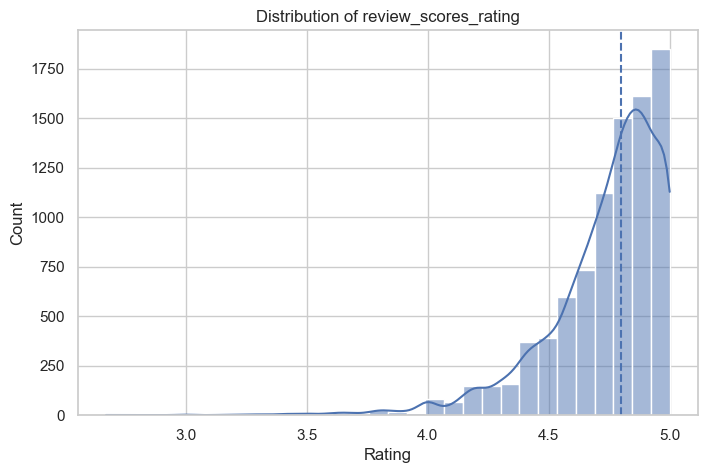

In [35]:
# ============================================================
# 4. Create the target and filter the classification sample
# ============================================================
class_df = prep_df.loc[
    (prep_df["number_of_reviews"].fillna(0) >= 5)
    & (prep_df["review_scores_rating"].notna())
].copy()

class_df["highly_rated"] = (class_df["review_scores_rating"] >= 4.8).astype(int)

print("Classification sample shape:", class_df.shape)
print("\nClass counts:")
print(class_df["highly_rated"].value_counts())
print("\nClass proportions:")
print(class_df["highly_rated"].value_counts(normalize=True).round(3))

# Optional: inspect the target distribution
plt.figure(figsize=(8, 5))
sns.histplot(class_df["review_scores_rating"], bins=30, kde=True)
plt.axvline(4.8, linestyle="--")
plt.title("Distribution of review_scores_rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

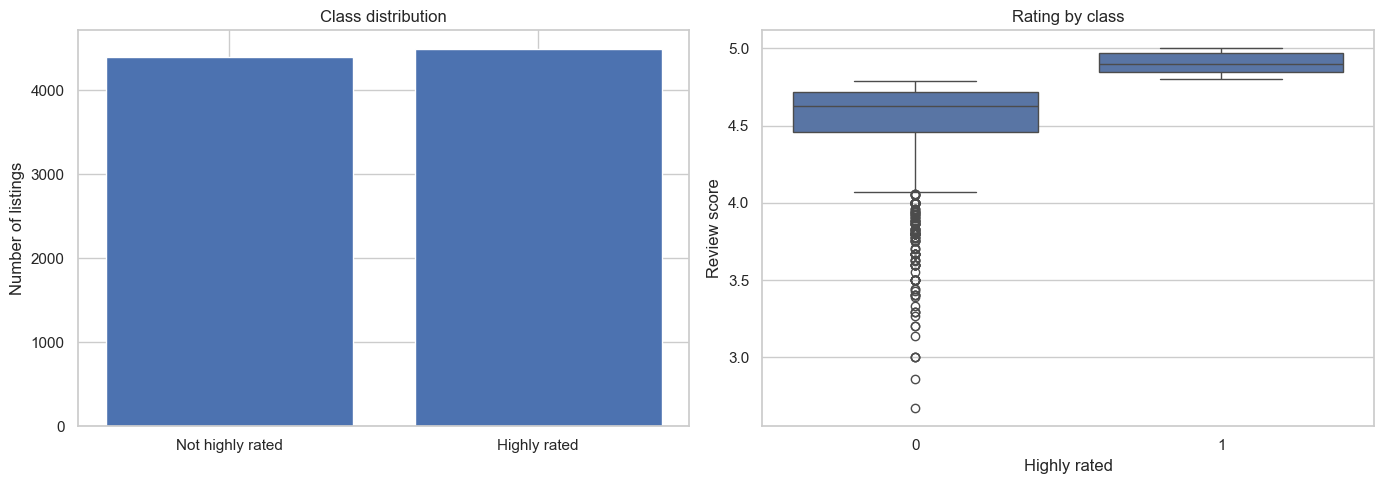

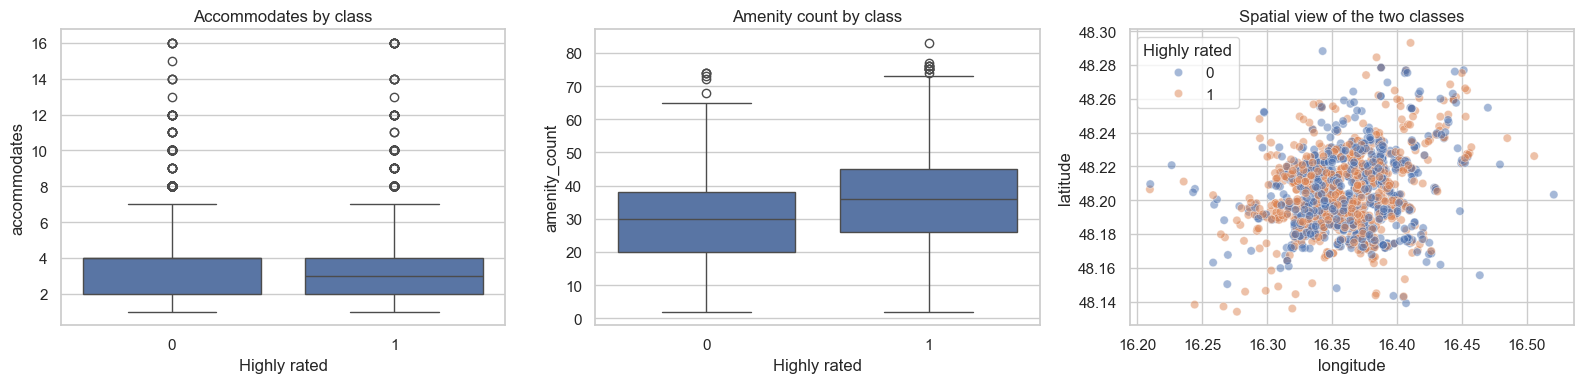

In [36]:
# ============================================================
# 5. Visualize the target and a few feature relationships
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = class_df["highly_rated"].value_counts().sort_index()
axes[0].bar(["Not highly rated", "Highly rated"], class_counts.values)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of listings")

sns.boxplot(
    data=class_df,
    x="highly_rated",
    y="review_scores_rating",
    ax=axes[1],
)
axes[1].set_title("Rating by class")
axes[1].set_xlabel("Highly rated")
axes[1].set_ylabel("Review score")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=class_df, x="highly_rated", y="accommodates", ax=axes[0])
axes[0].set_title("Accommodates by class")
axes[0].set_xlabel("Highly rated")

sns.boxplot(data=class_df, x="highly_rated", y="amenity_count", ax=axes[1])
axes[1].set_title("Amenity count by class")
axes[1].set_xlabel("Highly rated")

sns.scatterplot(
    data=class_df.sample(min(2000, len(class_df)), random_state=RANDOM_STATE),
    x="longitude",
    y="latitude",
    hue="highly_rated",
    alpha=0.5,
    ax=axes[2],
)
axes[2].set_title("Spatial view of the two classes")
axes[2].legend(title="Highly rated")

plt.tight_layout()
plt.show()

## Semi-goal 3 — Choose features intentionally

The feature list below follows your requested best-performing setup for classification.

We split the inputs into:

- **numeric features**
- **categorical features**

This is important because the two groups need different preprocessing.

In [37]:
# ============================================================
# 6. Feature lists for the classification task
# ============================================================

numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review",
    "amenity_count",
    "calculated_host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_joined",
    "host_response_time",
]

X = class_df[numeric_features + categorical_features].copy()
y = class_df["highly_rated"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

## If your target variable (y_class) has 80% Class A and 20% Class B, 
## using stratify=y_class guarantees that 
## both the training and testing sets maintain this 80/20 split.

print("Training shape:", X_train.shape)
print("Testing shape: ", X_test.shape)
print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

Training shape: (6664, 23)
Testing shape:  (2222, 23)

Numeric features:
['latitude', 'longitude', 'accommodates', 'bathrooms_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'host_response_rate_num', 'host_acceptance_rate_num', 'host_is_superhost_num', 'instant_bookable_num', 'host_tenure_days', 'days_since_last_review', 'amenity_count', 'calculated_host_listings_count']

Categorical features:
['room_type', 'property_type', 'neighbourhood_joined', 'host_response_time']


## Recall: why we split the data before fitting the preprocessor?

Before we train a machine learning model, it helps to think of the model as a **black box**.

A black-box model is a system where we mainly focus on:

- what goes **in** → the input features
- what comes **out** → the prediction

For example:

- in a **classification** problem, the inputs might be listing location, number of beds, or host features, and the output might be whether a listing is **highly rated**
- in a **regression** problem, the inputs might be similar features, but the output might be the **price**


The model learns from the **training data** and then we test whether it can make good predictions on **new unseen data**.

---

## Recall: why preprocessing is needed before the model

Real-world data usually cannot be sent directly into a machine learning model.

Some columns may have:

- missing values
- very different numeric scales
- text categories that must be converted into numbers

So before the data enters the model, we often need to do several preparation steps such as:

- **imputing** missing values
- **scaling** numeric features
- **encoding** categorical features


## The importance of `ColumnTransformer`

In many datasets, not all columns should be treated the same way.

For example:

- **numeric columns** may need imputation and scaling
- **categorical columns** may need imputation and one-hot encoding

`ColumnTransformer` lets us say:

- apply one set of steps to the numeric columns
- apply another set of steps to the categorical columns

So it acts like a traffic controller that sends different types of columns through different preprocessing routes.

---

## Recall: why we split the data before fitting the preprocessor

The **test set** should behave like a **final exam**.

That means:

- the model should **not** see the test set during training
- the preprocessing steps should **not learn** from the test set
- the test set should be used only at the end to check how well the model generalizes

This is extremely important.

Suppose we fill missing values using the average of the **whole dataset**, or scale values using statistics from the **whole dataset**.  
Then information from the test set has already leaked into the training process.

This is called **data leakage**.

Data leakage makes the model look better than it really is, because the test set is no longer truly unseen.

---

## The correct order

The correct workflow is:

1. split the data into **training** and **test** sets
2. fit the preprocessing steps using **only the training set**
3. train the model using the processed **training set**
4. apply the same learned preprocessing to the **test set**
5. evaluate model performance on the test set

When we use a `Pipeline`, this process becomes much safer and easier to manage.

---
---

## The importance of `Pipeline`

A **pipeline** is a way to connect all steps of a machine learning workflow into one ordered process.

Instead of doing each step separately and manually, we tell Python:

1. first preprocess the data
2. then send the processed data into the model
3. then make predictions

So a pipeline is like an **assembly line**:

**raw data → preprocessing steps → model → predictions**

This is useful because it keeps everything together in one place.

---

## Pipelines make life easier

Pipelines are helpful for several reasons:

### 1. They reduce mistakes
Without a pipeline, it is easy to forget a step, or apply different steps to training and test data.

### 2. They keep the workflow organized
All preprocessing and modeling steps are stored in one object, so the code is cleaner and easier to read.

### 3. They make evaluation fair
When we use a pipeline correctly, the model only learns preprocessing information from the training set.

### 4. They make model comparison easier
We can swap one model for another while keeping the same preprocessing setup.

For example, we will show later how we can compare Logistic Regression, KNN, and Decision Tree using the same pipeline structure.

---
---

## In simple words

A pipeline helps us treat machine learning as one complete workflow:

- prepare the data
- train the model
- make predictions correctly

And by splitting the data **before fitting the preprocessor**, we make sure the test set remains a fair and honest check of model performance.

Let's use the concept of `Pipeline` and `ColumnTransformer` to learn and implement practical machine learning algorithms.

## Semi-goal 4 — build one classifier step by step

We start with **Logistic Regression** because it is a very common baseline classifier.

We will build the full workflow in small pieces:

1. numeric preprocessing branch  
2. categorical preprocessing branch  
3. combined preprocessor  
4. full pipeline  
5. **Fit** (train), **Predict** (test), and **Evaluate**

In [38]:
# ============================================================
# 7. Numeric preprocessing branch: We define a pipleine 
#    with imputing and scaling steps
# ============================================================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


## Understanding the `Pipelines` and `steps`

Let's break down the code we just wrote:

* **`Pipeline(...)`**: This tells Python we are building a new sequence of data processing tasks.
* **`steps=[ ... ]`**: This is a list (enclosed in square brackets `[]`) that contains the exact sequence of operations. *The order here matters!*

**Inside the steps, we have two tasks (grouped in parentheses):**

1. **`("imputer", SimpleImputer(strategy="median"))`**
   * **`"imputer"`**: This is simply a nickname we give this step so we can identify it easily.
   * **`SimpleImputer(...)`**: This is the actual Python tool doing the work. It scans our numeric columns for missing values (blanks or NaNs) and automatically fills them in with the **median** value of that column.

2. **`("scaler", StandardScaler())`**
   * **`"scaler"`**: The nickname for our second step.
   * **`StandardScaler()`**: This is the tool that **scales** our data as we have disscussed earlier.

**How it works in action:** When raw numeric data enters this pipeline, it *first* gets its missing values filled (imputed). Then, that fixed data is immediately handed over to be scaled. The final output is perfectly clean numeric data!

In [39]:
# ============================================================
# 8. Categorical preprocessing branch: We define a pipleline
#    with imputing and onehot coding steps
# ============================================================
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

The categorical branch also does two jobs:

- fill **missing categories** using the most frequent category
- convert **text categories** into machine-readable indicator columns using one-hot encoding

In [40]:
# ============================================================
# 9. Combine both branches with a ColumnTransformer
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bathrooms_num', 'bedrooms', 'beds',
                                  'minimum_nights', 'maximum_nights',
                                  'availability_365', 'number_of_reviews',
                                  'reviews_per_month', 'host_response_rate_num',
                                  'host_acceptance_rate_num',
                                  'host_is_superhost_num',
                                  'instant_bookable_num', 'host_tenure_days',
                                  'days_since_last_review', 'amenity_count',
                                  'calculated_host_listings_count']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['room_type', 'property_type',
                                  'neighbourhood_joined',
                                  'host_response_time'])])

In [41]:
# ============================================================
# 10. Build the first full pipeline: Logistic Regression
# ============================================================
logistic_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000)),
    ]
)

logistic_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'accommodates',
                                                   'bathrooms_num', 'bedrooms',
                                                   'beds', 'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'host_response_rate_nu...
                                                   'host_tenure_days',
                                                   'days_since_last_review',
                                                   'amenity_count',
                                                   'calculated_host_listings_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['room_type', 'property_type',
                                                   'neighbourhood_joined',
                                                   'host_response_time'])])),
                ('classifier', LogisticRegression(max_iter=3000))])

### Our logistic regression ML model is built! 

Here is exactly what happens to our data when we run it through the `logistic_pipe`. Notice how the data splits into two separate "cleaning branches" before coming back together for the final prediction.

```text
                     [ RAW AIRBNB DATA ]
                              │
          ┌───────────────────┴───────────────────┐
          ▼                                       ▼
  (numeric_features)                    (categorical_features)
  e.g., bedrooms, minimum_nights        e.g., room_type, neighbourhood
          │                                       │
          │                                       │
[ numeric_transformer ]                 [ categorical_transformer ]
          │                                       │
          ├─► 1. Imputer (Median)                 ├─► 1. Imputer (Most frequent)
          │                                       │
          ├─► 2. Scaler (StandardScaler)          ├─► 2. OneHotEncoder (Text to 0s/1s)
          │                                       │
          ▼                                       ▼
          └───────────────────┬───────────────────┘
                              │
                      [ preprocessor ]
                 (The ColumnTransformer merges 
                 the two clean branches back 
                 into one single dataset)
                              │
                              ▼
                     [ logistic_pipe ]
             (We build this model for next step to train and test!)

In [42]:
# ============================================================
# 11. Fit the first model and make predictions
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score

logistic_pipe.fit(X_train, y_train)
logistic_pred = logistic_pipe.predict(X_test)

logistic_metrics = pd.DataFrame(
    [{
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, logistic_pred),
        "Precision": precision_score(y_test, logistic_pred),
        "Recall": recall_score(y_test, logistic_pred),
        "F1-score": f1_score(y_test, logistic_pred), 
    }]
)

display(logistic_metrics)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.716922,0.724954,0.708816,0.716794


### Complete ML workflow

Here is the entire journey of our data, from the raw CSV file all the way to our final evaluation metrics. Notice how our `logistic_pipe` does the heavy lifting for both the training and testing phases!

```text
                           [ RAW AIRBNB DATA ]
                                    │
                       [ Train / Test split (75/25) ]
                                    │
                 ┌──────────────────┴──────────────────┐
                 ▼                                     ▼
         [ X_train, y_train ]                  [ X_test, y_test ]
           (Training data)                       (Hidden testing data)
                 │                                     │
                 ▼                                     │
         [ logistic_pipe.fit() ]                       │
    1. Preprocesses X_train                            │
    2. Learns the mathematical patterns                │
                 │                                     │
                 ├─────────────────────────────────────┘
                 ▼
       [ logistic_pipe.predict() ]
    1. Preprocesses X_test (automatically!)
    2. Makes prediction
                 │
                 ▼
          [ Predictions ] ────────► Compared against ◄──────── [ y_test ]
                                          │                      (True answers)
                                          ▼
                         [ Metrics: Accuracy, Precision, Recall, F1-score ]

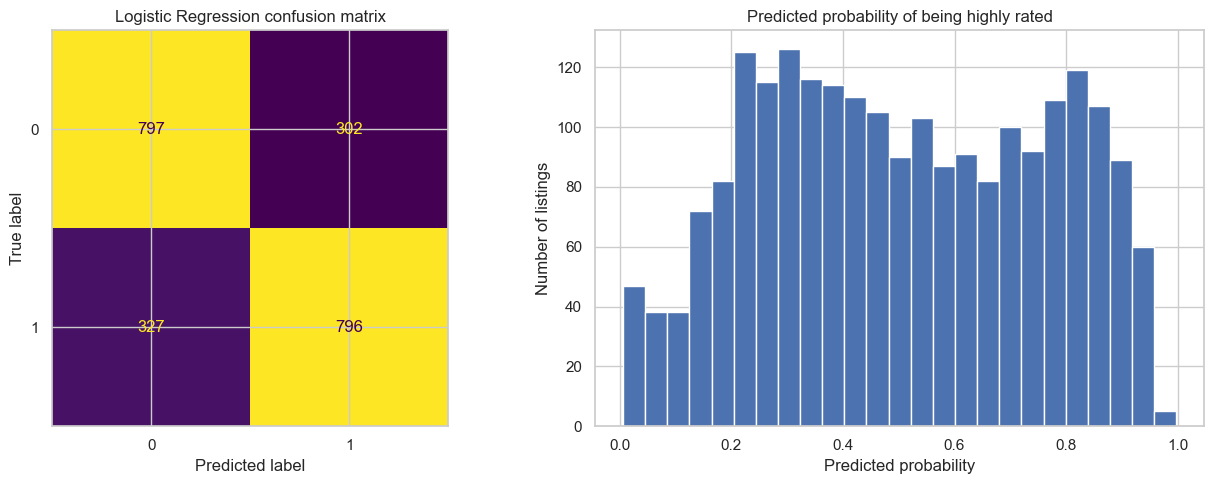

Accuracy : 0.7169
Precision: 0.725
Recall   : 0.7088
F1-score : 0.7168


In [43]:
# ============================================================
# 12. Confusion matrix and probability view for the first model
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

logistic_probs = logistic_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Logistic Regression confusion matrix")

axes[1].hist(logistic_probs, bins=25)
axes[1].set_title("Predicted probability of being highly rated")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Number of listings")

plt.tight_layout()
plt.show()

print("Accuracy :", round(accuracy_score(y_test, logistic_pred), 4))
print("Precision:", round(precision_score(y_test, logistic_pred), 4))
print("Recall   :", round(recall_score(y_test, logistic_pred), 4))
print("F1-score :", round(f1_score(y_test, logistic_pred), 4))

## Semi-goal 5 — A reusable helper function

The next step is not a new machine-learning idea.
It is a **programming convenience**.

We already know how to build and test one model.
Now we wrap the same logic into a helper function so we can reuse it for several classifiers.

The code below is deliberately over-commented so that students can follow what every line is doing.

In [51]:
# ============================================================
# 13. Helper function for processed classifiers
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_pipeline_classifiers(models, preprocessor, X_train, X_test, y_train, y_test):
    # We will store one summary row per model in this list.
    rows = []

    # We keep the fitted pipelines so that we can inspect or reuse them later.
    fitted_pipelines = {}

    # We also keep the predictions of each model for plots such as confusion matrices.
    predictions = {}

    # Loop over the dictionary: each item gives us a model name and the model object.
    for model_name, model in models.items():

        # Build a complete pipeline for this model:
        # first preprocess the data, then apply the classifier.
        pipe = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", model),
            ]
        )

        # Learn all preprocessing parameters and model parameters from the training data only.
        pipe.fit(X_train, y_train)

        # Use the fitted pipeline to predict the labels of unseen test examples.
        y_pred = pipe.predict(X_test)

        # Compute a few standard classification metrics and save them as one dictionary.
        rows.append(
            {
                "Model": model_name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred),
                "Recall": recall_score(y_test, y_pred),
                "F1-score": f1_score(y_test, y_pred),
            }
        )

        # Save the trained pipeline under its name.
        fitted_pipelines[model_name] = pipe

        # Save the predictions under the same name so we can plot them later.
        predictions[model_name] = y_pred

    # Turn the list of dictionaries into a clean comparison table.
    results = (
        pd.DataFrame(rows)
        .sort_values("Accuracy", ascending=False)
        .reset_index(drop=True)
    )

    # Return all useful objects so we can keep working with them.
    return results, fitted_pipelines, predictions

### 🔄 The helper function workflow: the "Model Loop"

Here is exactly what happens inside our `evaluate_pipeline_classifiers` function. Instead of writing the pipeline code 3 separate times, we let Python do the heavy lifting in a loop!

```text
  [ 📥 INPUTS: Dictionary of Models, Preprocessor, Train/Test Data ]
                                 │
                                 ▼
  ╔═══════════════════════════════════════════════════════════════╗
  ║ 🔄 LOOP: For each Model in our dictionary (e.g., KNN, Tree)   ║
  ║                                                               ║
  ║   1. ⚙️ Create a fresh Pipeline (Preprocessor + Model)        ║
  ║                        │                                      ║
  ║   2. 🧠 Fit the pipeline on (X_train, y_train)                ║
  ║                        │                                      ║
  ║   3. 🔮 Make predictions on (X_test)                          ║
  ║                        │                                      ║
  ║   4. 📐 Calculate Accuracy, Precision, Recall, and F1-score   ║
  ║                        │                                      ║
  ║   5. 💾 Save the metrics, the pipeline, and the predictions   ║
  ╚═══════════════════════════════════════════════════════════════╝
               │ (Repeats until all models are done)
               ▼
  [ 📊 WRAP UP: Convert saved metrics into a sorted Table ]
               │
               ▼
  [ 🏆 RETURN: 1. Results Table, 2. Pipelines, 3. Predictions ]

## Semi-goal 6 — Train multiple classifiers

We now use the same preprocessor for three classification models:

- Logistic Regression
- K-Nearest Neighbours
- Decision Tree

This is a useful teaching pattern:

> keep the data preparation fixed, and change only the model.

That way, the comparison is much fairer.

In [45]:
# ============================================================
# 14. Compare multiple classification models
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_leaf=10,
    ),
}

classification_results, classification_pipes, classification_preds = evaluate_pipeline_classifiers(
    classification_models,
    preprocessor,
    X_train,
    X_test,
    y_train,
    y_test,
)

display(classification_results)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.716922,0.724954,0.708816,0.716794
1,Decision Tree,0.716472,0.720680,0.716830,0.718750
2,KNN,0.705221,0.712727,0.698130,0.705353


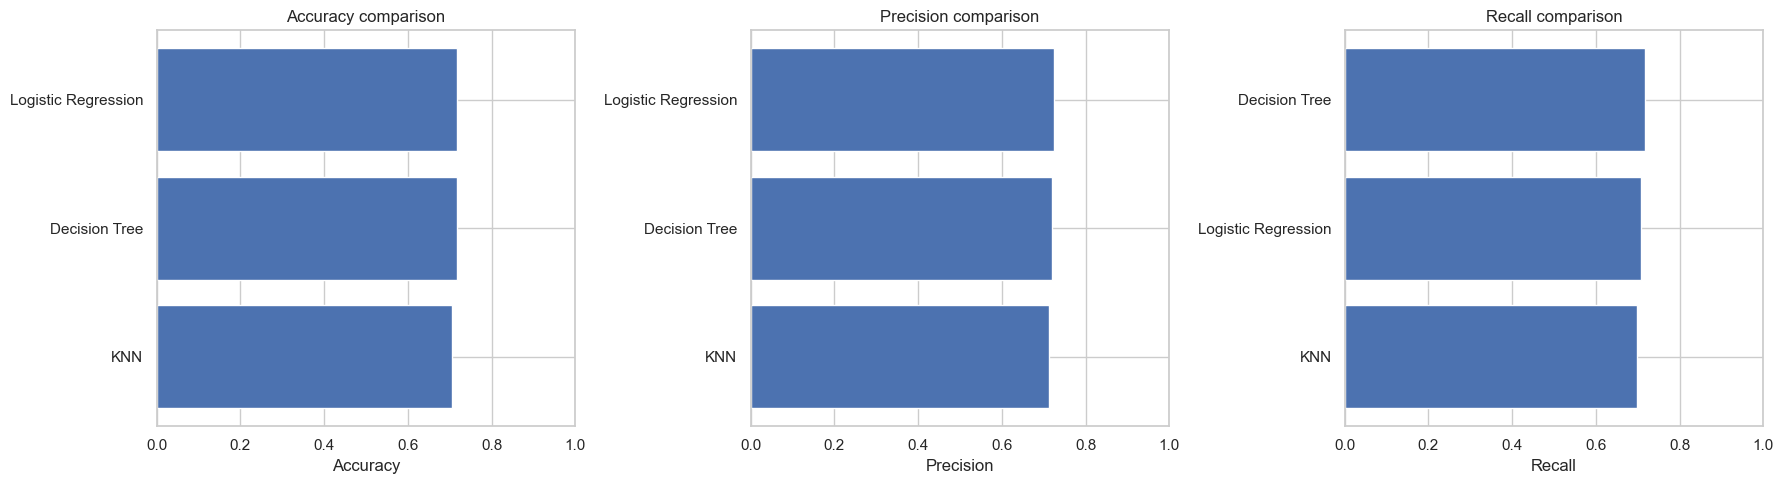

In [46]:
# ============================================================
# 15. Visual comparison of the three classifiers
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_names = ["Accuracy", "Precision", "Recall"]

for ax, metric in zip(axes, metric_names):
    ordered = classification_results.sort_values(metric, ascending=True)
    ax.barh(ordered["Model"], ordered[metric])
    ax.set_xlim(0, 1)
    ax.set_title(f"{metric} comparison")
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

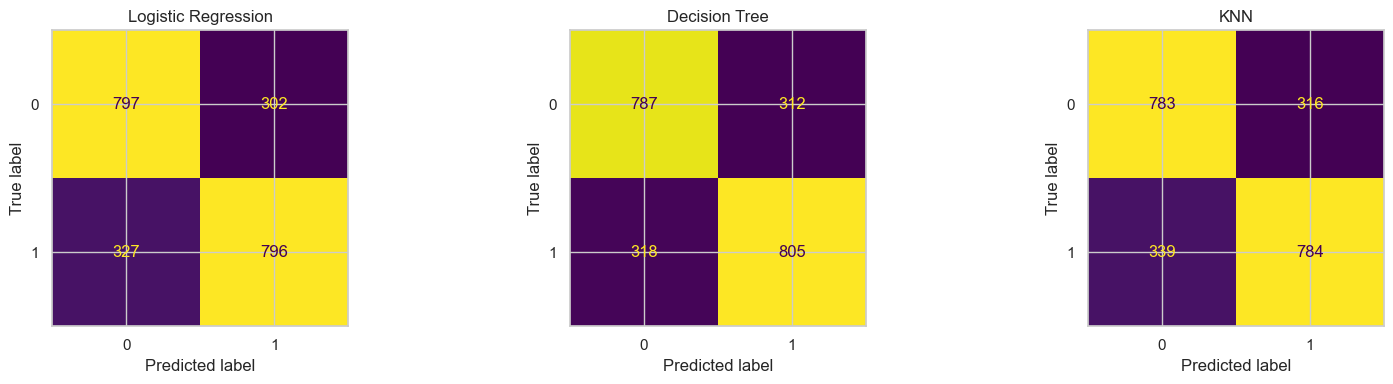

In [47]:
# ============================================================
# 16. Confusion matrices for all three classifiers
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, model_name in zip(axes, classification_results["Model"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        classification_preds[model_name],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

,feature,importance
13,num__host_is_superhost_num,0.370255
18,num__calculated_host_listings_count,0.219391
17,num__amenity_count,0.052297
0,num__latitude,0.048878
9,num__number_of_reviews,0.048320
8,num__availability_365,0.042819
15,num__host_tenure_days,0.037211
6,num__minimum_nights,0.030939
1,num__longitude,0.023942
11,num__host_response_rate_num,0.020479


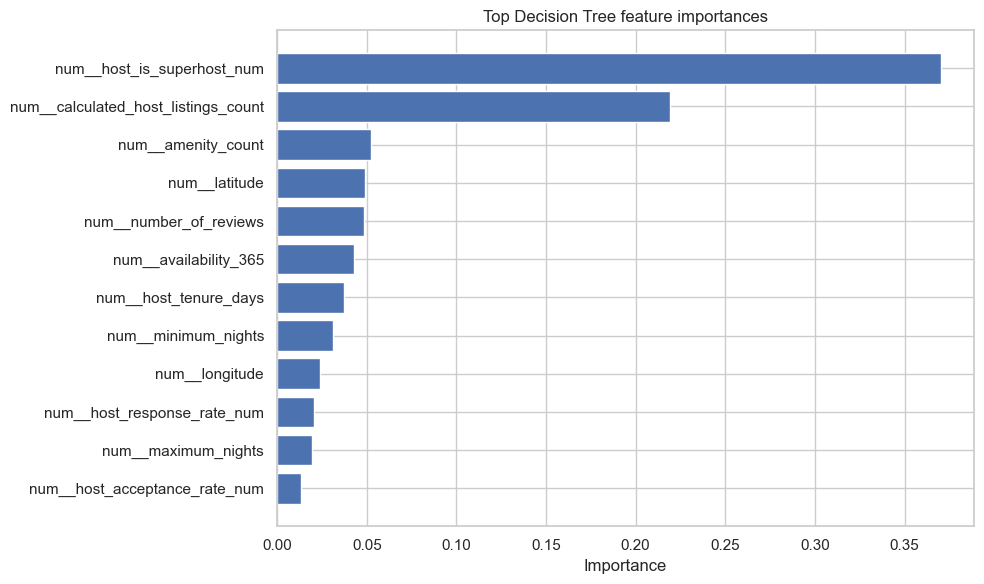

In [48]:
# ============================================================
# 17. What did the Decision Tree focus on?
# ============================================================
tree_pipe = classification_pipes["Decision Tree"]
fitted_preprocessor = tree_pipe.named_steps["preprocessor"]
fitted_tree = tree_pipe.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_tree.feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
top_features = importance_df.head(12).sort_values("importance", ascending=True)
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Decision Tree feature importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Semi-goal 7 — A simple hyperparameter playground

Students often first meet machine learning as:

> choose a model and press fit

But real modeling also involves choices called **hyperparameters**.

Here we keep the idea simple:

- for KNN, try different values of `k`
- see how test accuracy changes

,k,Accuracy
0,3,0.689469
1,5,0.698920
2,7,0.702970
3,9,0.704770
4,11,0.704320
5,13,0.707471
6,15,0.705221
7,17,0.711971
8,19,0.707021
9,21,0.706121


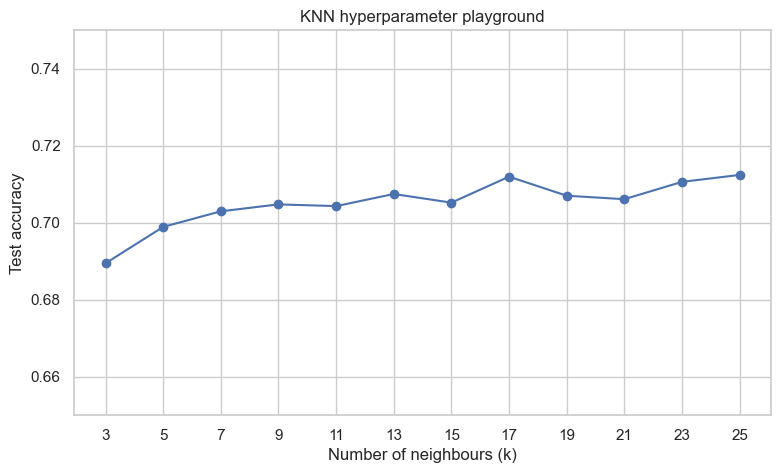

In [49]:
# ============================================================
# 18. Hyperparameter playground for KNN
# ============================================================
k_values = list(range(3, 26, 2))
knn_rows = []

for k in k_values:
    knn_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    knn_pipe.fit(X_train, y_train)
    knn_pred = knn_pipe.predict(X_test)
    knn_rows.append(
        {
            "k": k,
            "Accuracy": accuracy_score(y_test, knn_pred),
        }
    )

knn_tuning = pd.DataFrame(knn_rows)
display(knn_tuning)

plt.figure(figsize=(9, 5))
plt.plot(knn_tuning["k"], knn_tuning["Accuracy"], marker="o")
plt.title("KNN hyperparameter playground")
plt.xlabel("Number of neighbours (k)")
plt.ylabel("Test accuracy")
plt.xticks(k_values)
plt.ylim(0.65, 0.75)
#plt.xlim(0.6, 0.8)
plt.show()

## Sub-goal 8 — Hyperparameter playground for Decision Trees

Just like KNN has `k` (the number of neighbors), a Decision Tree has `max_depth`. 

The `max_depth` hyperparameter controls how many layers of "Yes/No" questions the tree is allowed to ask before making a final guess. 
* If `max_depth` is too low, the tree is too simple and cannot find patterns (Underfitting).
* If `max_depth` is too high, the tree essentially memorizes the training data perfectly, but fails to generalize to new, unseen Airbnb listings (Overfitting).

Let's test depths from 1 to 15 and see what happens to our accuracy!

,max_depth,Accuracy
0,1,0.693519
1,2,0.702970
2,3,0.719172
3,4,0.723672
4,5,0.721422
5,6,0.720522
6,7,0.713771
7,8,0.720522
8,9,0.708371
9,10,0.708821


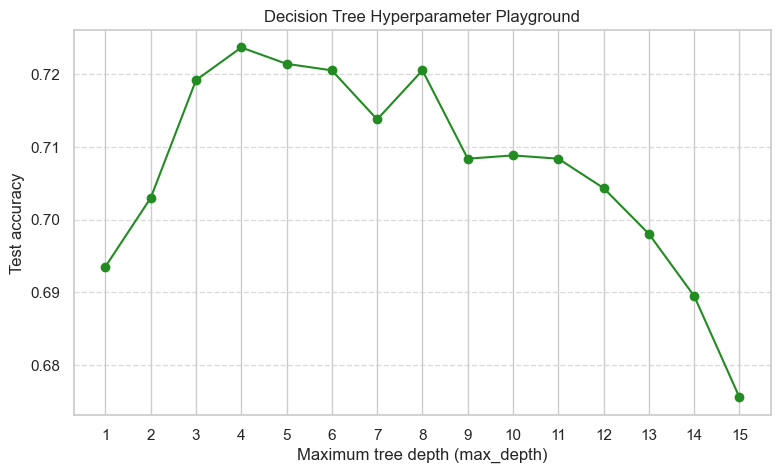

In [50]:
# ============================================================
# 19. Hyperparameter playground for Decision Tree
# ============================================================
from sklearn.tree import DecisionTreeClassifier

# Let's test tree depths from 1 (very simple) to 16 (very complex)
depth_values = list(range(1, 16))
dt_rows = []

for depth in depth_values:
    dt_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            # random_state=42 ensures all students get the exact same results
            ("classifier", DecisionTreeClassifier(max_depth=depth, random_state=42)),
        ]
    )
    
    # Train and predict
    dt_pipe.fit(X_train, y_train)
    dt_pred = dt_pipe.predict(X_test)
    
    # Save the results
    dt_rows.append(
        {
            "max_depth": depth,
            "Accuracy": accuracy_score(y_test, dt_pred),
        }
    )

# Create a clean table
dt_tuning = pd.DataFrame(dt_rows)
display(dt_tuning)

# Plot the results
plt.figure(figsize=(9, 5))
plt.plot(dt_tuning["max_depth"], dt_tuning["Accuracy"], marker="o", color="forestgreen")
plt.title("Decision Tree Hyperparameter Playground")
plt.xlabel("Maximum tree depth (max_depth)")
plt.ylabel("Test accuracy")
plt.xticks(depth_values)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a light grid to make it easier to read
plt.show()

## 🎉 Final summary: What you have achieved

Congratulations on building your first full Machine Learning pipeline! In this notebook, you went from raw, messy data to a functioning AI model. 

Here is the complete journey you just mastered:

* **Handled geospatial data:** You took raw Airbnb locations and successfully gave them spatial context (neighborhoods).
* **Defined a target:** You transformed a vague goal into a concrete classification task (Highly Rated vs. Not).
* **Built an assembly line:** You learned how to preprocess messy numbers and text categories automatically using a `ColumnTransformer`.
* **Trained your first model:** You built and tested a Logistic Regression model step-by-step.
* **Scaled up with code:** You used a custom helper function to quickly test and compare multiple models (KNN and Decision Trees) without rewriting your pipeline.
* **Tuned the engine:** You explored how changing a hyperparameter (like maximum tree depth) drastically changes how a model learns.

**What is next?**
In your upcoming graded assignment, you get to be the lead Data Scientist. You will use this exact same framework, but you will be tasked with implementing **new classifiers** (like Support Vector Machines and Random Forests) on your own. 
